In [ ]:
pip install tensorflow numpy

In [ ]:
from tensorflow.keras.datasets import mnist
import numpy as np

## 1. Preparing the Dataset

We start by loading the MNIST dataset. Since MobileNetV2 is pre-trained on three-channel RGB images of size 224x224, we make a few adjustments to match its expected input shape:

- Reshape the images from grayscale (28x28, 1 channel) to RGB (28x28, 3 channels).
- Resize images to 32x32 pixels, aligning with our model’s configuration.
- Normalize pixel values to fall between 0 and 1 by dividing by 255.

In [5]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = np.stack([train_images]*3, axis=-1) / 255.0
test_images = np.stack([test_images]*3, axis=-1) / 255.0

train_images = tf.image.resize(train_images, [32, 32])
test_images = tf.image.resize(test_images, [32, 32])

train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

2026-03-26 18:26:48.602296: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Building the Model

We load MobileNetV2 with pre-trained weights from ImageNet excluding the fully connected top layers to customize for our 10-class classification task:

- Freeze the base model to retain learned features and avoid overfitting.
- Add a global average pooling layer to reduce model complexity.
- Add a dense layer with softmax activation for the output classes.

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False  # Freeze base model

inputs = Input(shape=(32, 32, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation='softmax')(x)
model = Model(inputs, outputs)

/tmp/ipykernel_55/3104373990.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


## 3. Compiling and Training the Model

The model is compiled with categorical cross-entropy as the loss function and accuracy as the evaluation metric. Using Adam optimizer we train the model on the MNIST training data for ten epochs.

In [8]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 31ms/step - accuracy: 0.4430 - loss: 1.8305 - val_accuracy: 0.6112 - val_loss: 1.2953
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.6092 - loss: 1.2627 - val_accuracy: 0.6415 - val_loss: 1.1386
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.6331 - loss: 1.1392 - val_accuracy: 0.6534 - val_loss: 1.0719
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.6511 - loss: 1.0750 - val_accuracy: 0.6601 - val_loss: 1.0359
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.6594 - loss: 1.0416 - val_accuracy: 0.6659 - val_loss: 1.0156
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.6645 - loss: 1.0171 - val_accuracy: 0.6660 - val_loss: 1.0006
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.6631 - loss: 1.0124 - val_accuracy: 0.6710 - val_loss: 0.9899
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.6713 -

## 4. Fine-Tuning the Model

After initial training we unfreeze the last few layers of the base model to perform fine-tuning. This allows the model to adjust high-level features for the MNIST data while retaining its foundational knowledge.

In [9]:
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 124s 74ms/step - accuracy: 0.2335 - loss: 10.6680 - val_accuracy: 0.1573 - val_loss: 12.0289
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 108s 72ms/step - accuracy: 0.4846 - loss: 2.4753 - val_accuracy: 0.2915 - val_loss: 2.3037
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 110s 73ms/step - accuracy: 0.6042 - loss: 1.5352 - val_accuracy: 0.6633 - val_loss: 1.1105
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 109s 72ms/step - accuracy: 0.6954 - loss: 1.0662 - val_accuracy: 0.8063 - val_loss: 0.6836
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 108s 72ms/step - accuracy: 0.7559 - loss: 0.8380 - val_accuracy: 0.8505 - val_loss: 0.5431


## 5. Model Evaluation

Once the model has been trained and fine-tuned we evaluate it on the test set, measuring its loss and accuracy. This step assesses how well the transfer learning model has adapted to the MNIST dataset and demonstrates its effectiveness in digit classification.

In [10]:
loss, accuracy = model.evaluate(test_images, test_labels)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8218 - loss: 0.6243
Test loss: 0.5776398181915283
Test accuracy: 0.8370000123977661


## 6. Visualizing Model Performance

To visualize the performance further a confusion matrix provides a breakdown of correct and incorrect classifications.

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step


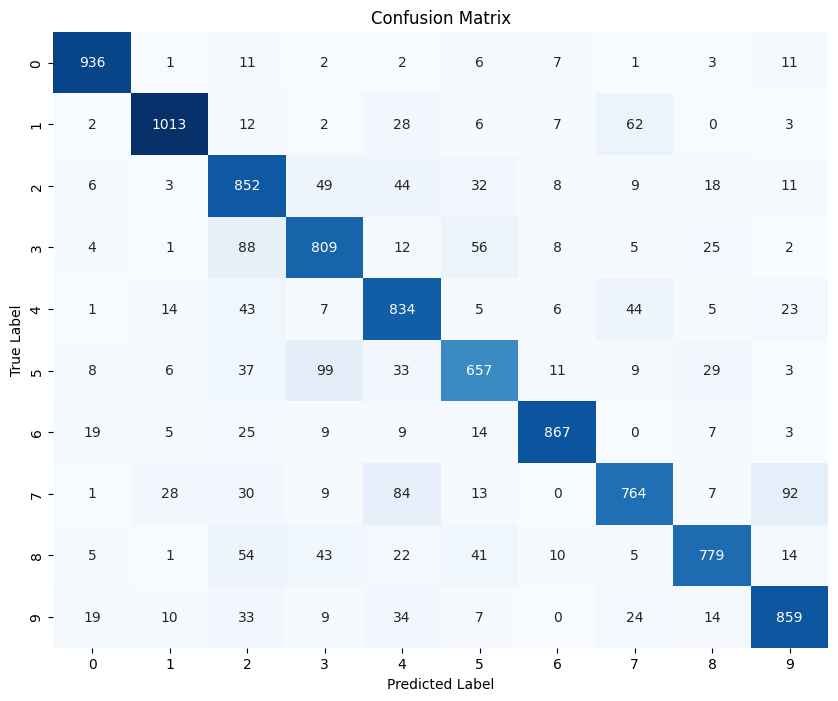

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_predictions = model.predict(test_images)
test_predictions_classes = np.argmax(test_predictions, axis=1)
test_true_classes = np.argmax(test_labels, axis=1)

cm = confusion_matrix(test_true_classes, test_predictions_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

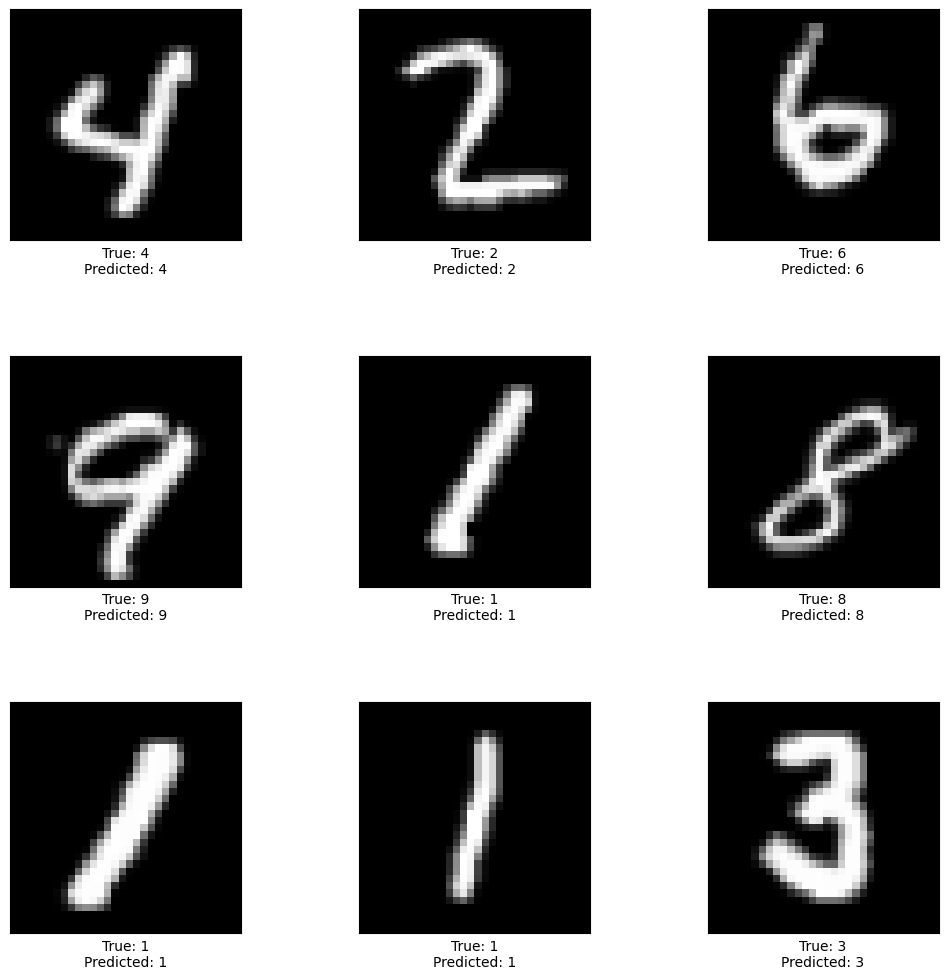

In [14]:
def display_sample(sample_images, sample_labels, sample_predictions):
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)

    for i, ax in enumerate(axes.flat):
        ax.imshow(sample_images[i].reshape(32, 32), cmap='gray')
        ax.set_xlabel(f"True: {sample_labels[i]}\nPredicted: {sample_predictions[i]}")
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()

test_images_gray = np.dot(test_images[...,:3], [0.2989, 0.5870, 0.1140])

random_indices = np.random.choice(len(test_images_gray), 9, replace=False)
sample_images = test_images_gray[random_indices]
sample_labels = test_true_classes[random_indices]
sample_predictions = test_predictions_classes[random_indices]
display_sample(sample_images, sample_labels, sample_predictions)